Shape: (5842, 2)
                                            Sentence Sentiment
0  The GeoSolutions technology will leverage Bene...  positive
1  $ESI on lows, down $1.50 to $2.50 BK a real po...  negative
2  For the last quarter of 2010 , Componenta 's n...  positive
3  According to the Finnish-Russian Chamber of Co...   neutral
4  The Swedish buyout firm has sold its remaining...   neutral
['Sentence', 'Sentiment']
Text column: Sentence
Label column: Sentiment

Label distribution:
Sentiment
neutral     3130
positive    1852
negative     860
Name: count, dtype: int64

Example texts:
["The GeoSolutions technology will leverage Benefon 's GPS solutions by providing Location Based Search Technology , a Communities Platform , location relevant multimedia content and a new and powerful commercial model .", '$ESI on lows, down $1.50 to $2.50 BK a real possibility', "For the last quarter of 2010 , Componenta 's net sales doubled to EUR131m from EUR76m for the same period a year earlier , whi

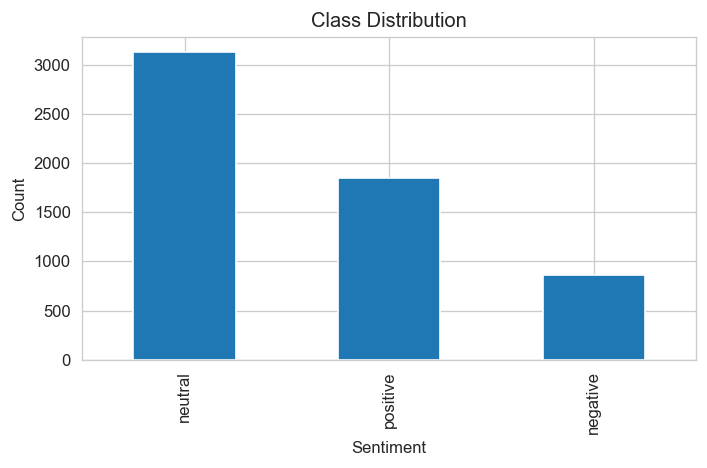

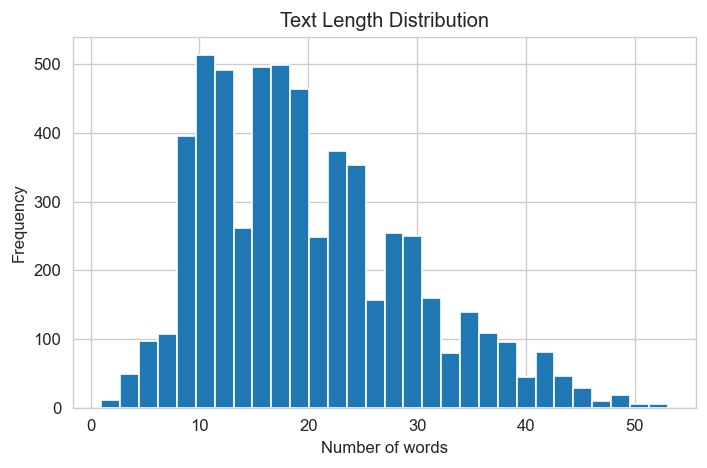

Train size: 4089
Validation size: 876
Test size: 877
Label order: ['negative', 'neutral', 'positive']
NB validation summary: {'model': 'Count + MultinomialNB', 'accuracy': 0.6963470319634704, 'macro_f1': 0.6092065974790922, 'weighted_f1': 0.6926086377433149}

NB per-class metrics:
       label  precision    recall        f1  support
0  negative   0.345133  0.302326  0.322314      129
1   neutral   0.770386  0.765458  0.767914      469
2  positive   0.713805  0.762590  0.737391      278

NB classification report:

              precision    recall  f1-score   support

    negative     0.3451    0.3023    0.3223       129
     neutral     0.7704    0.7655    0.7679       469
    positive     0.7138    0.7626    0.7374       278

    accuracy                         0.6963       876
   macro avg     0.6098    0.6101    0.6092       876
weighted avg     0.6898    0.6963    0.6926       876



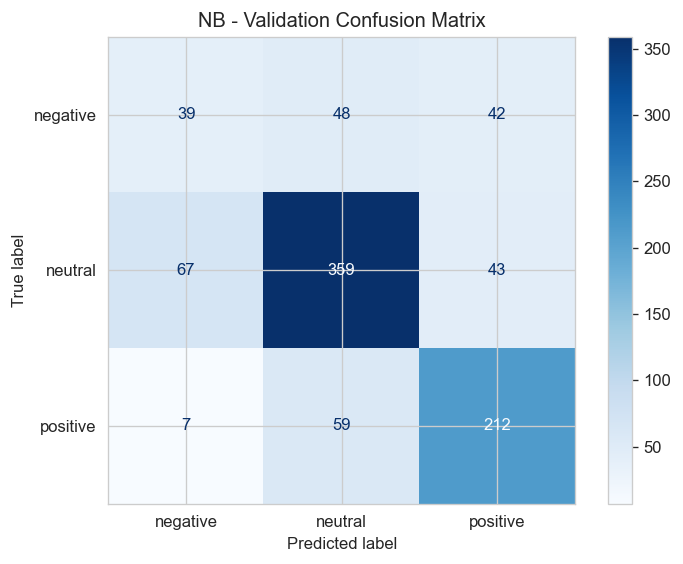

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best params: {'clf__C': 5.0, 'vect__min_df': 2, 'vect__ngram_range': (1, 1)}
Best CV macro F1: 0.5870110635727152
LR validation summary: {'model': 'TF-IDF + LogisticRegression', 'accuracy': 0.6723744292237442, 'macro_f1': 0.5611486843897153, 'weighted_f1': 0.6625887930302707}

LR classification report:

              precision    recall  f1-score   support

    negative     0.2347    0.1783    0.2026       129
     neutral     0.7088    0.7889    0.7467       469
    positive     0.7656    0.7050    0.7341       278

    accuracy                         0.6724       876
   macro avg     0.5697    0.5574    0.5611       876
weighted avg     0.6570    0.6724    0.6626       876



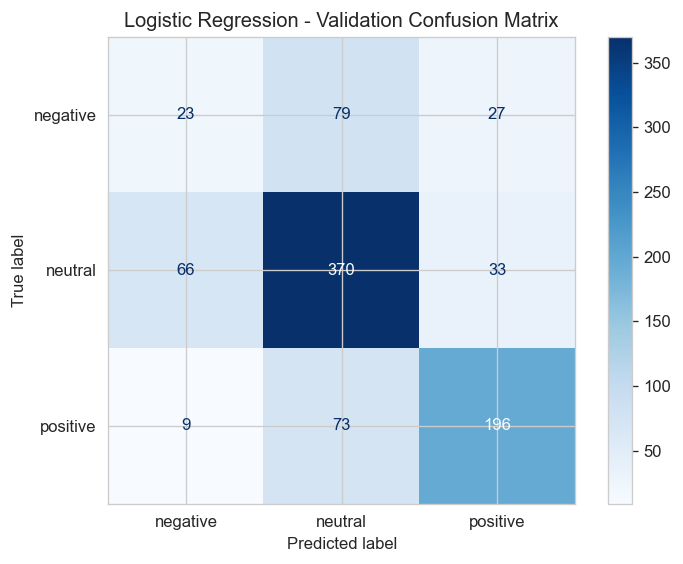

                         model  accuracy  macro_f1  weighted_f1
0        Count + MultinomialNB  0.696347  0.609207     0.692609
1  TF-IDF + LogisticRegression  0.672374  0.561149     0.662589
Final test summary: {'model': 'Count + MultinomialNB', 'accuracy': 0.7001140250855188, 'macro_f1': 0.6240188814695099, 'weighted_f1': 0.6952355302569944}

Final test classification report:

              precision    recall  f1-score   support

    negative     0.4434    0.3643    0.4000       129
     neutral     0.7581    0.7936    0.7755       470
    positive     0.6953    0.6978    0.6966       278

    accuracy                         0.7001       877
   macro avg     0.6323    0.6186    0.6240       877
weighted avg     0.6919    0.7001    0.6952       877



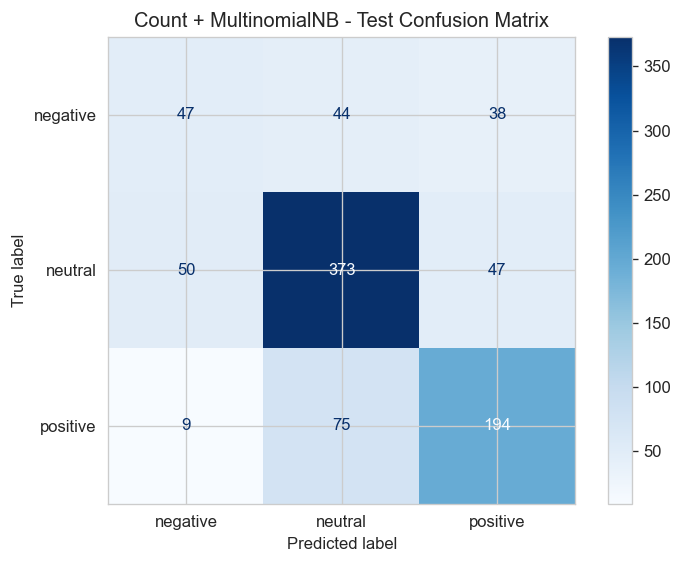

Number of test errors: 263

Sample errors:
    true     pred                                                                                                                                                                                                                                                                                             text
negative  neutral                                                                                                                                                                                                                                                             arm slammed by handset sales outlook
negative positive                                                                                                                                                                                                                                           $fb $aapl $nke $jwn bearish charts keep getting worse.
negative  neutral                   

In [6]:
# =========================
# Task 2: Financial News Sentiment Classification
# Recommended notebook structure
# =========================

# Cell 1: imports
import re
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

RANDOM_STATE = 42
plt.rcParams["figure.dpi"] = 120


# Cell 2: load data
# Replace with your real path if needed
df = pd.read_csv("data.csv")

print("Shape:", df.shape)
print(df.head())
print(df.columns.tolist())


# Cell 3: identify text and label columns
# Adjust these if your file uses different names
possible_text_cols = ["text", "sentence", "phrase", "news", "content", "Sentence"]
possible_label_cols = ["label", "sentiment", "target", "class", "Sentiment"]

text_col = None
label_col = None

for c in possible_text_cols:
    if c in df.columns:
        text_col = c
        break

for c in possible_label_cols:
    if c in df.columns:
        label_col = c
        break

if text_col is None or label_col is None:
    raise ValueError(
        f"Could not automatically detect text/label columns.\n"
        f"Columns found: {df.columns.tolist()}\n"
        f"Please set text_col and label_col manually."
    )

print("Text column:", text_col)
print("Label column:", label_col)


# Cell 4: basic cleaning
df = df[[text_col, label_col]].dropna().copy()
df[text_col] = df[text_col].astype(str)
df[label_col] = df[label_col].astype(str).str.strip().str.lower()

# Keep only expected labels if needed
valid_labels = {"positive", "negative", "neutral"}
if set(df[label_col].unique()) - valid_labels:
    print("Warning: unexpected labels found:", set(df[label_col].unique()) - valid_labels)

df = df[df[label_col].isin(valid_labels)].copy()

print("\nLabel distribution:")
print(df[label_col].value_counts())

print("\nExample texts:")
print(df[text_col].head(5).tolist())


# Cell 5: lightweight preprocessing
# Keep this simple and explain it in the report
def preprocess_text(text: str) -> str:
    text = text.lower()
    text = re.sub(r"\s+", " ", text)               # collapse spaces
    text = re.sub(r"http\S+|www\.\S+", " URL ", text)
    text = re.sub(r"[^a-z0-9%\$\.\-\s]", " ", text)  # keep some finance-relevant chars
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["clean_text"] = df[text_col].apply(preprocess_text)

# Optional: quick negation handling
# You can test this later as an improvement experiment
def add_simple_negation_markers(text: str) -> str:
    tokens = text.split()
    neg_words = {"not", "no", "never", "n't"}
    new_tokens = []
    negate = False

    for tok in tokens:
        if tok in neg_words:
            negate = True
            new_tokens.append(tok)
            continue

        if negate:
            new_tokens.append("NOT_" + tok)
            negate = False
        else:
            new_tokens.append(tok)

    return " ".join(new_tokens)

# Uncomment below if you want to test negation handling
# df["clean_text"] = df["clean_text"].apply(add_simple_negation_markers)


# Cell 6: quick EDA for report
df["text_len_words"] = df["clean_text"].str.split().apply(len)

print("\nAverage text length (words):", round(df["text_len_words"].mean(), 2))
print("Median text length (words):", round(df["text_len_words"].median(), 2))

# Plot class distribution
plt.figure(figsize=(6, 4))
df[label_col].value_counts().plot(kind="bar")
plt.title("Class Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# Plot text length distribution
plt.figure(figsize=(6, 4))
plt.hist(df["text_len_words"], bins=30)
plt.title("Text Length Distribution")
plt.xlabel("Number of words")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


# Cell 7: train / validation / test split
X = df["clean_text"]
y = df[label_col]

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=RANDOM_STATE,
    stratify=y_temp
)

print("Train size:", len(X_train))
print("Validation size:", len(X_val))
print("Test size:", len(X_test))


# Cell 8: define models
nb_pipeline = Pipeline([
    ("vect", CountVectorizer(
        lowercase=False,      # already cleaned
        ngram_range=(1, 2),
        min_df=2
    )),
    ("clf", MultinomialNB())
])

lr_pipeline = Pipeline([
    ("vect", TfidfVectorizer(
        lowercase=False,      # already cleaned
        ngram_range=(1, 2),
        min_df=2,
        sublinear_tf=True,
        max_features=10000
    )),
    ("clf", LogisticRegression(
        max_iter=2000,
        random_state=RANDOM_STATE,
        multi_class="auto"
    ))
])


# Cell 9: helper functions
def evaluate_model(name, model, X_train, y_train, X_eval, y_eval, label_order=None):
    model.fit(X_train, y_train)
    preds = model.predict(X_eval)

    acc = accuracy_score(y_eval, preds)
    macro_f1 = f1_score(y_eval, preds, average="macro")
    weighted_f1 = f1_score(y_eval, preds, average="weighted")

    p, r, f1, s = precision_recall_fscore_support(
        y_eval, preds, labels=label_order, zero_division=0
    )

    per_class_df = pd.DataFrame({
        "label": label_order,
        "precision": p,
        "recall": r,
        "f1": f1,
        "support": s
    })

    summary = {
        "model": name,
        "accuracy": acc,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1
    }

    return model, preds, summary, per_class_df


def show_confusion(y_true, y_pred, labels, title):
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot(cmap="Blues", values_format="d")
    plt.title(title)
    plt.tight_layout()
    plt.show()


def error_analysis_dataframe(X_eval, y_true, y_pred, n=20):
    out = pd.DataFrame({
        "text": X_eval.reset_index(drop=True),
        "true": y_true.reset_index(drop=True),
        "pred": pd.Series(y_pred)
    })
    out["correct"] = out["true"] == out["pred"]
    errors = out[~out["correct"]].copy()
    return errors.head(n), errors


label_order = sorted(y.unique().tolist())
print("Label order:", label_order)


# Cell 10: baseline on validation set
nb_model, nb_val_pred, nb_val_summary, nb_val_class = evaluate_model(
    "Count + MultinomialNB",
    nb_pipeline,
    X_train, y_train,
    X_val, y_val,
    label_order=label_order
)

print("NB validation summary:", nb_val_summary)
print("\nNB per-class metrics:\n", nb_val_class)
print("\nNB classification report:\n")
print(classification_report(y_val, nb_val_pred, digits=4))

show_confusion(y_val, nb_val_pred, label_order, "NB - Validation Confusion Matrix")


# Cell 11: logistic regression tuning on validation set
param_grid = {
    "vect__ngram_range": [(1, 1), (1, 2)],
    "vect__min_df": [2, 3],
    "clf__C": [0.1, 1.0, 5.0]
}

lr_grid = GridSearchCV(
    estimator=lr_pipeline,
    param_grid=param_grid,
    scoring="f1_macro",
    cv=5,
    n_jobs= 1,
    verbose=1
)

lr_grid.fit(X_train, y_train)

print("Best params:", lr_grid.best_params_)
print("Best CV macro F1:", lr_grid.best_score_)

best_lr = lr_grid.best_estimator_

lr_val_pred = best_lr.predict(X_val)
lr_val_summary = {
    "model": "TF-IDF + LogisticRegression",
    "accuracy": accuracy_score(y_val, lr_val_pred),
    "macro_f1": f1_score(y_val, lr_val_pred, average="macro"),
    "weighted_f1": f1_score(y_val, lr_val_pred, average="weighted")
}
print("LR validation summary:", lr_val_summary)
print("\nLR classification report:\n")
print(classification_report(y_val, lr_val_pred, digits=4))

show_confusion(y_val, lr_val_pred, label_order, "Logistic Regression - Validation Confusion Matrix")


# Cell 12: compare validation results
val_results = pd.DataFrame([nb_val_summary, lr_val_summary]).sort_values(
    by="macro_f1", ascending=False
)
print(val_results)


# Cell 13: choose best model, retrain on train+val, final test evaluation
X_train_final = pd.concat([X_train, X_val], axis=0)
y_train_final = pd.concat([y_train, y_val], axis=0)

# choose best
final_model = best_lr if lr_val_summary["macro_f1"] >= nb_val_summary["macro_f1"] else nb_pipeline
final_model_name = "TF-IDF + LogisticRegression" if final_model is best_lr else "Count + MultinomialNB"

final_model.fit(X_train_final, y_train_final)
test_pred = final_model.predict(X_test)

test_summary = {
    "model": final_model_name,
    "accuracy": accuracy_score(y_test, test_pred),
    "macro_f1": f1_score(y_test, test_pred, average="macro"),
    "weighted_f1": f1_score(y_test, test_pred, average="weighted")
}

print("Final test summary:", test_summary)
print("\nFinal test classification report:\n")
print(classification_report(y_test, test_pred, digits=4))

show_confusion(y_test, test_pred, label_order, f"{final_model_name} - Test Confusion Matrix")


# Cell 14: error analysis
sample_errors, all_errors = error_analysis_dataframe(X_test, y_test, test_pred, n=25)

print("Number of test errors:", len(all_errors))
print("\nSample errors:")
print(sample_errors[["true", "pred", "text"]].to_string(index=False))


# Cell 15: save results for report
val_results.to_csv("task2_validation_results.csv", index=False)
sample_errors.to_csv("task2_sample_errors.csv", index=False)

print("Saved:")
print("- task2_validation_results.csv")
print("- task2_sample_errors.csv")


# Cell 16: optional interpretation for logistic regression
# Only works cleanly if final model is logistic regression
if "LogisticRegression" in str(type(final_model.named_steps["clf"])):
    vectorizer = final_model.named_steps["vect"]
    clf = final_model.named_steps["clf"]
    feature_names = np.array(vectorizer.get_feature_names_out())

    for i, class_name in enumerate(clf.classes_):
        coefs = clf.coef_[i]
        top_pos_idx = np.argsort(coefs)[-15:][::-1]
        top_neg_idx = np.argsort(coefs)[:15]

        print(f"\nTop positive features for class '{class_name}':")
        print(feature_names[top_pos_idx])

        print(f"\nTop negative/opposing features for class '{class_name}':")
        print(feature_names[top_neg_idx])


# Cell 17: optional improvement experiment
# Example: test negation-marked text
# You can rerun the whole pipeline with:
# df["clean_text_neg"] = df["clean_text"].apply(add_simple_negation_markers)
# and compare whether macro_f1 improves.